# Retail Sales Analytics & Sales Prediction

## Step 7: Sales Prediction using Machine Learning

### Objective

Machine Learning allows computers to learn patterns from historical data and use those patterns to make predictions.

In this section, we will build a basic **Linear Regression model** to predict retail sales using historical Superstore data.

The machine learning workflow will include:

- Loading the cleaned dataset
- Preparing data for prediction
- Selecting input features
- Selecting the target variable
- Splitting data into training and testing sets
- Training a Linear Regression model
- Predicting sales
- Evaluating model performance
- Comparing actual and predicted sales

## 1. Import Required Libraries

We will use:

- **Pandas** for data manipulation
- **NumPy** for numerical operations
- **Matplotlib** and **Seaborn** for visualization
- **Scikit-learn** for machine learning

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Machine Learning libraries imported successfully!")

Machine Learning libraries imported successfully!


## 2. Load the Cleaned Dataset

The cleaned Superstore dataset created during preprocessing will be used for machine learning.

In [3]:
df = pd.read_csv("cleaned_superstore.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 9800
Columns: 23


## 3. Inspect Available Features

Before building the prediction model, we need to decide which dataset columns can be used as input features.

The model requires numerical input, so categorical text columns will later need to be converted into numerical form.

In [4]:
print("Available columns:\n")

for column in df.columns:
    print(column)

Available columns:

Row ID
Order ID
Order Date
Ship Date
Ship Mode
Customer ID
Customer Name
Segment
Country
City
State
Postal Code
Region
Product ID
Category
Sub-Category
Product Name
Sales
Order Year
Order Month
Order Month Name
Order Quarter
Shipping Days


## 4. Select Features and Target Variable

### Target Variable

The target variable is the value that the machine learning model will attempt to predict.

For this project:

**Target = Sales**

### Input Features

We will use a combination of time-related, shipping, product, customer, and geographical information as model inputs:

- Order Year
- Order Month
- Order Quarter
- Shipping Days
- Category
- Region
- Segment
- Ship Mode

In [5]:
features = [
    "Order Year",
    "Order Month",
    "Order Quarter",
    "Shipping Days",
    "Category",
    "Region",
    "Segment",
    "Ship Mode"
]

target = "Sales"

ml_data = df[features + [target]].copy()

ml_data.head()

,Order Year,Order Month,Order Quarter,Shipping Days,Category,Region,Segment,Ship Mode,Sales
0,2017,11,4,3,Furniture,South,Consumer,Second Class,261.9600
1,2017,11,4,3,Furniture,South,Consumer,Second Class,731.9400
2,2017,6,2,4,Office Supplies,West,Corporate,Second Class,14.6200
3,2016,10,4,7,Furniture,South,Consumer,Standard Class,957.5775
4,2016,10,4,7,Office Supplies,South,Consumer,Standard Class,22.3680


## 5. Check the Machine Learning Dataset

Before training a model, we will verify that the selected data does not contain missing values.

In [6]:
print("Machine Learning dataset shape:")
print(ml_data.shape)

print("\nMissing values:")
print(ml_data.isnull().sum())

Machine Learning dataset shape:
(9800, 9)

Missing values:
Order Year       0
Order Month      0
Order Quarter    0
Shipping Days    0
Category         0
Region           0
Segment          0
Ship Mode        0
Sales            0
dtype: int64


## 6. Identify Numerical and Categorical Features

Machine learning algorithms such as Linear Regression work with numerical values.

Some of our features are already numerical, while others contain text categories.

### Numerical Features

- Order Year
- Order Month
- Order Quarter
- Shipping Days

### Categorical Features

- Category
- Region
- Segment
- Ship Mode

The categorical features must be converted into numerical form before training the model.

In [8]:
numerical_features = [
    "Order Year",
    "Order Month",
    "Order Quarter",
    "Shipping Days"
]

categorical_features = [
    "Category",
    "Region",
    "Segment",
    "Ship Mode"
]

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Order Year', 'Order Month', 'Order Quarter', 'Shipping Days']

Categorical Features:
['Category', 'Region', 'Segment', 'Ship Mode']


## 7. Encode Categorical Variables

Categorical variables contain text values that cannot be used directly by Linear Regression.

We will use **One-Hot Encoding** to convert categorical values into numerical columns.

Pandas provides the `get_dummies()` function for this purpose.

In [10]:
ml_encoded = pd.get_dummies(
    ml_data,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

print("Categorical features encoded successfully!")

print("\nOriginal columns:", ml_data.shape[1])
print("Encoded columns:", ml_encoded.shape[1])

ml_encoded.head()

Categorical features encoded successfully!

Original columns: 9
Encoded columns: 15


,Order Year,Order Month,Order Quarter,Shipping Days,Sales,Category_Office Supplies,Category_Technology,Region_East,Region_South,Region_West,Segment_Corporate,Segment_Home Office,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class
0,2017,11,4,3,261.9600,0,0,0,1,0,0,0,0,1,0
1,2017,11,4,3,731.9400,0,0,0,1,0,0,0,0,1,0
2,2017,6,2,4,14.6200,1,0,0,0,1,1,0,0,1,0
3,2016,10,4,7,957.5775,0,0,0,1,0,0,0,0,0,1
4,2016,10,4,7,22.3680,1,0,0,1,0,0,0,0,0,1


## 8. Define Input Features (X) and Target (y)

Machine learning commonly uses:

- `X` to represent the input features
- `y` to represent the target variable

For this project, `X` contains the information used to make a prediction, while `y` contains the actual Sales values.

In [11]:
X = ml_encoded.drop("Sales", axis=1)
y = ml_encoded["Sales"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nNumber of input features:", X.shape[1])

X shape: (9800, 14)
y shape: (9800,)

Number of input features: 14


## 9. Split the Dataset into Training and Testing Sets

The dataset will be divided into two parts:

- **80% Training Data** — used by the model to learn patterns
- **20% Testing Data** — used to evaluate the model on unseen data

This helps us determine whether the model can generalize beyond the data it learned from.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

print("\n Training and testing data created successfully!")

Training records: 7840
Testing records: 1960

 Training and testing data created successfully!


## 10. Machine Learning Preparation Summary

The dataset is now prepared for machine learning.

The following steps have been completed:

- Cleaned dataset loaded
- Target variable selected
- Input features selected
- Numerical and categorical variables identified
- Categorical variables converted using One-Hot Encoding
- Input data stored in `X`
- Sales target stored in `y`
- Dataset divided into 80% training data and 20% testing data

The next step will train a Linear Regression model and evaluate its sales predictions.

In [14]:
print("=" * 60)
print("STEP 7A: MACHINE LEARNING DATA PREPARATION")
print("=" * 60)

print("\nTarget variable: Sales")
print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])
print("Input features after encoding:", X_train.shape[1])

print("\nMissing values in X:", X.isnull().sum().sum())
print("Missing values in y:", y.isnull().sum())

print("\n STEP 7A COMPLETED SUCCESSFULLY!")

STEP 7A: MACHINE LEARNING DATA PREPARATION

Target variable: Sales
Training records: 7840
Testing records: 1960
Input features after encoding: 14

Missing values in X: 0
Missing values in y: 0

 STEP 7A COMPLETED SUCCESSFULLY!


## 11. Create the Linear Regression Model

Linear Regression is a supervised machine learning algorithm used to predict numerical values.

Since our target variable `Sales` is numerical, we will use Linear Regression to learn relationships between the selected input features and historical sales values.

In [17]:
model = LinearRegression()

print("Linear Regression model created successfully!")

Linear Regression model created successfully!


## 12. Train the Linear Regression Model

The model will now learn patterns from the training dataset.

- `X_train` contains the training input features.
- `y_train` contains the actual Sales values corresponding to those features.

The `fit()` function is used to train the model.

In [18]:
model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


## 13. Make Sales Predictions

After training, the model will predict Sales values for the testing dataset.

The model has not been trained using these testing records, which allows us to evaluate how well it performs on unseen data.

In [19]:
y_pred = model.predict(X_test)

print("Sales predictions created successfully!")

print("\nNumber of predictions:", len(y_pred))

Sales predictions created successfully!

Number of predictions: 1960


## 14. Compare Actual and Predicted Sales

To understand the model's predictions, we will compare the actual Sales values from the testing dataset with the Sales values predicted by the Linear Regression model.

In [20]:
comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

comparison.head(10)

,Actual Sales,Predicted Sales
0,47.940,340.197316
1,11.360,134.724317
2,10.950,404.990703
3,17.480,126.119459
4,21.120,125.318211
5,88.832,131.990519
6,6.672,115.357474
7,22.480,104.594280
8,251.580,101.746922
9,38.256,123.003128


## 15. Mean Absolute Error (MAE)

Mean Absolute Error measures the average absolute difference between actual and predicted Sales values.

A lower MAE indicates that the predictions are, on average, closer to the actual values.

In [21]:
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Absolute Error (MAE): ${mae:,.2f}")

Mean Absolute Error (MAE): $274.59


## 16. Root Mean Squared Error (RMSE)

Root Mean Squared Error measures the typical magnitude of prediction errors while giving greater importance to large errors.

A lower RMSE generally indicates better predictive performance.

In [23]:
mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")

Root Mean Squared Error (RMSE): $800.56


## 17. R² Score

R² measures how much of the variation in the target variable can be explained by the model.

A value closer to 1 generally indicates that the model explains more of the variation in Sales.

A low or negative R² indicates that the selected features and Linear Regression model have limited ability to explain Sales variation.

In [24]:
r2 = r2_score(y_test, y_pred)

print(f"R² Score: {r2:.4f}")

R² Score: 0.0411


## 18. Model Evaluation Results

We will display the main evaluation metrics together to summarize the performance of the Linear Regression model.

In [25]:
print("=" * 55)
print("LINEAR REGRESSION MODEL PERFORMANCE")
print("=" * 55)

print(f"MAE:  ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"R²:    {r2:.4f}")

LINEAR REGRESSION MODEL PERFORMANCE
MAE:  $274.59
RMSE: $800.56
R²:    0.0411


## 19. Actual vs Predicted Sales

A scatter plot can be used to compare actual Sales values with the model's predicted values.

If predictions are highly accurate, the points should generally follow the diagonal reference line.

Large distances from the line indicate larger prediction errors.

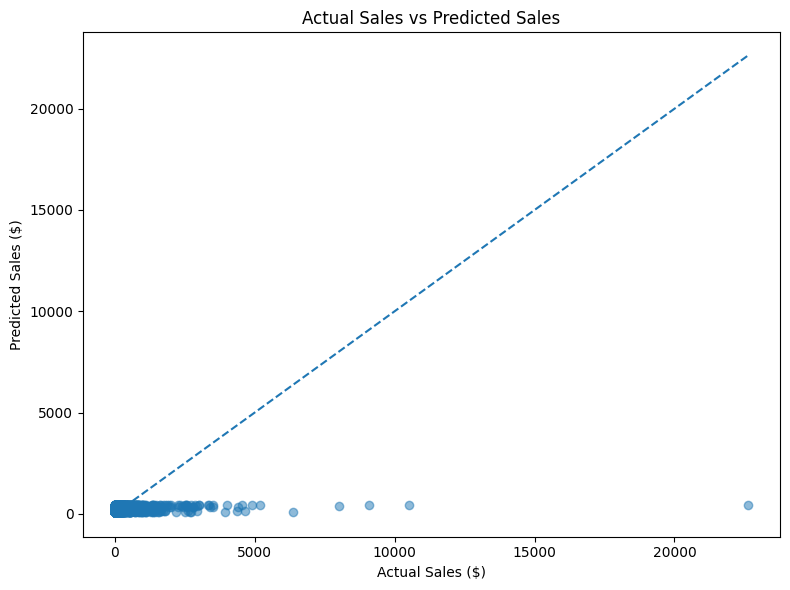

In [26]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.title("Actual Sales vs Predicted Sales")
plt.xlabel("Actual Sales ($)")
plt.ylabel("Predicted Sales ($)")

plt.tight_layout()
plt.show()

## 20. Analyze Prediction Errors

Prediction error represents the difference between actual Sales and predicted Sales.

Analyzing these errors helps us understand where the model makes larger or smaller prediction mistakes.

In [27]:
comparison["Error"] = (
    comparison["Actual Sales"] -
    comparison["Predicted Sales"]
)

comparison["Absolute Error"] = comparison["Error"].abs()

comparison.head(10)

,Actual Sales,Predicted Sales,Error,Absolute Error
0,47.940,340.197316,-292.257316,292.257316
1,11.360,134.724317,-123.364317,123.364317
2,10.950,404.990703,-394.040703,394.040703
3,17.480,126.119459,-108.639459,108.639459
4,21.120,125.318211,-104.198211,104.198211
5,88.832,131.990519,-43.158519,43.158519
6,6.672,115.357474,-108.685474,108.685474
7,22.480,104.594280,-82.114280,82.114280
8,251.580,101.746922,149.833078,149.833078
9,38.256,123.003128,-84.747128,84.747128


## 21. Largest Prediction Errors

We will identify the testing records where the difference between actual and predicted Sales is the largest.

This helps reveal limitations of the current Linear Regression model.

In [28]:
largest_errors = comparison.sort_values(
    "Absolute Error",
    ascending=False
).head(10)

largest_errors

,Actual Sales,Predicted Sales,Error,Absolute Error
1271,22638.480,425.214409,22213.265591,22213.265591
1351,10499.970,426.655228,10073.314772,10073.314772
1109,9099.930,424.481812,8675.448188,8675.448188
728,7999.980,407.113101,7592.866899,7592.866899
1174,6354.950,109.992805,6244.957195,6244.957195
1885,5199.960,424.250479,4775.709521,4775.709521
1602,4663.736,127.690983,4536.045017,4536.045017
295,4899.930,417.924389,4482.005611,4482.005611
1088,4355.168,131.692825,4223.475175,4223.475175
810,4548.810,437.861618,4110.948382,4110.948382


## 22. Average Actual and Predicted Sales

Comparing the average actual and predicted Sales values provides an additional high-level view of model behavior.

In [29]:
print(
    f"Average Actual Sales: "
    f"${comparison['Actual Sales'].mean():,.2f}"
)

print(
    f"Average Predicted Sales: "
    f"${comparison['Predicted Sales'].mean():,.2f}"
)

Average Actual Sales: $269.45
Average Predicted Sales: $219.50


## 23. Model Interpretation

A basic Linear Regression model was developed to predict Sales using historical order, shipping, product category, customer segment, and regional information.

The model was evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score
- Actual vs Predicted Sales visualization

The evaluation results show that sales prediction is challenging using only the selected features and a basic linear model.

Retail sales can be influenced by many factors that are not available in this dataset, such as discounts, product prices, quantities, promotions, holidays, economic conditions, and customer purchasing behavior.

Therefore, this Linear Regression model should be considered a **basic baseline prediction model** rather than a production-level forecasting system.

Future improvements could include additional predictive features, feature engineering, and more advanced machine learning algorithms.

# Sales Prediction Summary

In this section, a basic Linear Regression machine learning model was developed to predict retail Sales.

### Machine Learning Workflow Completed

1. Loaded the cleaned retail dataset
2. Selected input features and target variable
3. Converted categorical variables using One-Hot Encoding
4. Split the dataset into training and testing sets
5. Created a Linear Regression model
6. Trained the model using historical data
7. Generated Sales predictions
8. Compared actual and predicted Sales
9. Calculated MAE
10. Calculated RMSE
11. Calculated R²
12. Visualized Actual vs Predicted Sales
13. Analyzed prediction errors

### Conclusion

The project demonstrates the complete basic machine learning workflow from data preparation to model evaluation.

The Linear Regression model provides a baseline for Sales prediction. Its performance also demonstrates that accurate retail Sales prediction may require additional variables and more advanced modeling techniques.

In [31]:
print("=" * 60)
print("STEP 7: SALES PREDICTION USING LINEAR REGRESSION")
print("=" * 60)

print("\nModel: Linear Regression")

print("\nDataset Split:")
print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

print("\nModel Performance:")
print(f"MAE:  ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"R²:    {r2:.4f}")

print("\n STEP 7 SALES PREDICTION COMPLETED SUCCESSFULLY!")

STEP 7: SALES PREDICTION USING LINEAR REGRESSION

Model: Linear Regression

Dataset Split:
Training records: 7840
Testing records: 1960

Model Performance:
MAE:  $274.59
RMSE: $800.56
R²:    0.0411

 STEP 7 SALES PREDICTION COMPLETED SUCCESSFULLY!
